# MirrorQATopo — Topological Boundary Experiment

Comparing `mode='full'` (all genuine qubits always paired) against
`mode='random'` (50:50 chance per even layer of f2f vs f2g outcome).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.transpiler import Target
from qiskit.quantum_info import Operator
from qiskit.circuit.library import CXGate
from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, MirrorQATopo, QuantumAwesomeness
from qiskit_device_benchmarking.bench_code.mrb import TopoUtil
import os, random

SEED = 123
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
basis_gates = ["id", "h", "x", "y", "z", "rz", "cx"]
p2 = 5e-2 # 1e-3 (0.1%), 1e-2 (1%), 5e-2 (5%)
p1 = p2 / 10
rz_angle = np.pi / 2
# error rate for paper: 0.1, 1, 5%

shots = 1000
lengths = [2] + [4, 10, 20, 50, 100] # *** Change this for the heavy sin graph.
# 25, 30, 35, 40, 45) and 80
# lengths = [20] + [26, 30, 36, 40, 46, 50, 56, 60]
# lengths = [40, 50, 60, 70, 80, 90]
num_samples = 100 # 100 for the paper (original notebook: 20)
num_lengths = len(lengths)

# Coupling map: 4x4 genuine lattice + 2 fake boundary qubits (18 nodes total)
cmap = TopoUtil.makeCouple(6, 6, 2, 'ibm')
num_qubits = len(list(cmap.physical_qubits))  # 18
legit_qubits = 36  # indices 0-15 are genuine; 16, 17 are fake
TopoUtil.checkCouple(cmap)

In [ ]:
target = Target.from_configuration(
    num_qubits=num_qubits,
    basis_gates=basis_gates,
    coupling_map=cmap, # Give it the coupling map that we just created.
    custom_name_mapping={
        "id": Operator(np.eye(2)),
        "h":  Operator(np.array([[1, 1], [1, -1]]) / np.sqrt(2)),
        "x":  Operator(np.array([[0, 1], [1, 0]])),
        "y":  Operator(np.array([[0, -1j], [1j, 0]])),
        "z":  Operator(np.array([[1, 0], [0, -1]])),
        "rz": Operator([[np.cos(rz_angle/2), -1j*np.sin(rz_angle/2)],
                         [-1j*np.sin(rz_angle/2), np.cos(rz_angle/2)]]),
        "cx": Operator(np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]])),
    },
)

noise_model = NoiseModel()
error_1q = depolarizing_error(p1, 1)
error_2q = depolarizing_error(p2, 2)
for gate in basis_gates:
    if gate in ["id", "h", "x", "y", "z", "rz"]:
        noise_model.add_all_qubit_quantum_error(error_1q, gate)
    elif gate == "cx":
        noise_model.add_all_qubit_quantum_error(error_2q, gate)

In [ ]:
backend = AerSimulator(
    method="stabilizer",
    noise_model=noise_model if (p1 > 0 or p2 > 0) else None,
    target=target,
    max_parallel_threads=0,
    max_parallel_experiments=0,
    seed_simulator=SEED,
)

Until above, everything is the same.<br/>
When we make the experiment object, give it 'full' or 'random' for `sampling_algorithm`.<br/>
For MirrorQATopo, there will be another parameter more than `sampling_algorithm`. <br/><br/>
The basic value for `sampling_algorithm` is `topo`, and within `topo`, there are two modes, either `full` or `random`. Choose either of those keywords.

```
makeCouple(num_rows, num_cols)
    └─▶ CouplingMap (genuine + fake edges)
            │
            ▼
    Target / Backend  (simulator knows about all 18 qubits)
            │
            ▼ MirrorQATopo(range(16), ...)
    _set_distribution_options()
    line 264: coupling_map.reduce(physical_qubits)   ← strips fake edges
            │
            ▼
    TopoSampler._select_edges_topo()
    — builds left/right columns algebraically from corners[1]+1
    — never reads fake-qubit connections from the coupling map
```

In [ ]:
exp = MirrorQATopo(
    range(legit_qubits),
    lengths=lengths,
    sampling_algorithm='topo',
    mode='random', # 'full': This mode is the same with NewSampler's behaviour.
    backend=backend,
    two_qubit_gate_density=0.5,
    num_samples=num_samples,
    initial_entangling_angle=np.pi / 2,
    seed=SEED,
)
exp.set_run_options(shots=shots)
rb_data = exp.run()
print(rb_data.job_ids)

for i in range(len(exp._pairs)):
    length = lengths[i % num_lengths]
    sample = i // num_lengths
    print(f"Circuit {i:3d} | length={length:3d}, sample={sample:2d}: "
          f"{len(exp._pairs[i])} pairs — {exp._pairs[i]}")

**Validation** — ground-truth outcome per circuit, derived from `exp._pairs` (sampler metadata, not MI).
- `f2f` if `len(pairs) == legit // 2` → all genuine qubits paired, nl–nr won the MWPM.
- `f2g` if `len(pairs) == legit // 2 − 1` → 2 genuine boundary qubits abandoned, nl/nr paired with boundary instead.

This oracle is **not** available to the bot — the bot can only see MI from measurement counts.

In [ ]:
all_legit = set(range(legit_qubits))                                                                        
                                                                                                              
print(f"{'Circuit':>7} | {'length':>6} | {'sample':>6} | {'outcome':>6} | {'pairs':>5} | abandoned")        
print("-" * 65)                                                                                             
for i, pairs in enumerate(exp._pairs):                                                                      
    length  = lengths[i % num_lengths]                  
    sample  = i // num_lengths                                                                              
    paired  = {q for p in pairs for q in p}
    singles = set(exp._singles[i])                                                                          
    abandoned = all_legit - paired - singles            
                                                                                                              
    outcome = 'f2f' if len(pairs) == legit_qubits // 2 else 'f2g'
    print(f"  {i:5d} | {length:6d} | {sample:6d} | {outcome:>6} | "                                         
          f"{len(pairs):5d} | {sorted(abandoned) if abandoned else '-'}")

**Standard analysis** — fit the effective-polarisation decay curve using `MirrorRBAnalysis`.

In [ ]:
exp.analysis.set_options(analyzed_quantity="Effective Polarization")
analysis = exp.analysis.run(rb_data)

In [ ]:
analysis.figure(0)

**MI analysis** — per-depth mutual information separated into *paired* (edge had an active CX in that circuit's first layer) vs *singles* (qubit had no 2Q partner).

`QuantumAwesomeness` takes the **genuine-only** coupling map — the fake boundary qubits (nl, nr) were never part of any circuit and must be excluded before computing MI.

In [ ]:
# [(j, k) for j, k in exp.backend.coupling_map if j < legit_qubits and k < legit_qubits]
# This can be easily written via qiskit.transpiler.CouplingMap.reduce().
# It will return the CouplingMap object, with the tuples (pairs) that we built.

legit_cmap = exp.backend.coupling_map.reduce(range(legit_qubits))
qa = QuantumAwesomeness(legit_cmap)

mi = qa.mutual_info(rb_data.data())
mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

num_lengths = len(lengths)
ys = [[[] for _ in range(num_lengths)] for _ in range(2)]
yerrs = [[], []]

for p, pairtype in enumerate(["paired", "singles"]):
    for j, m in enumerate(mmi[pairtype]):
        if m is not np.nan:
            ys[p][j % num_lengths].append(m)
    for j in range(num_lengths):
        yerrs[p].append(np.std(ys[p][j]))
        ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths, ys[0], yerr=yerrs[0], label="paired")
plt.errorbar(lengths, ys[1], yerr=yerrs[1], label="singles")
plt.yscale("log")
plt.legend()

### Bot!

In [ ]:
import networkx as nx
from collections import defaultdict

# --- Helper: Determine TopoSampler mode from fake qubit connectivity ---
def get_topo_mode(topo_full, legit_qubits, fake_qubits):
    # topo_full: list of all MWPM pairs (tuples)
    # fake_qubits: set of fake qubit indices (e.g., {16, 17})
    # Returns: 'f2f' if fake qubits paired with each other, 'f2g' if paired with genuine
    fake_pairs = [p for p in topo_full if any(q in fake_qubits for q in p)]
    if not fake_pairs:
        return 'f2f'  # No fake qubits paired, all genuine paired
    # If both fake qubits are paired together, it's f2f
    for p in fake_pairs:
        if all(q in fake_qubits for q in p):
            return 'f2f'
    return 'f2g'

half = legit_qubits // 2
fake_qubits = set(range(legit_qubits, num_qubits))

bot_vs_topo_pairs = defaultdict(int)
bot_vs_topo_mode = defaultdict(int)
bot_vs_pairs_pairs = defaultdict(int)
topo_vs_pairs_ok = defaultdict(int)
total_by_len = defaultdict(int)

for i, info in enumerate(mi):
    length = lengths[i % num_lengths]
    sample = i // num_lengths

    # 1. TopoSampler MWPM (all pairs, incl. fake)
    topo_full = exp._topo_outcomes[i]
    topo_genuine = sorted(
        tuple(sorted((u, v)))
        for u, v in topo_full
        if u < legit_qubits and v < legit_qubits
    )
    topo_mode = get_topo_mode(topo_full, legit_qubits, fake_qubits)

    # 2. Bot guess (MI-MWPM)
    G = nx.Graph()
    for (u, v), w in info.items():
        G.add_edge(u, v, weight=w)
    raw_guess = nx.max_weight_matching(G, maxcardinality=False, weight="weight")
    bot_pairs = sorted(tuple(sorted(p)) for p in raw_guess)
    bot_mode = "f2f" if len(bot_pairs) == half else "f2g"

    matched_mi = [info[p] for p in bot_pairs if p in info]
    mean_mi = np.mean(matched_mi) if matched_mi else float("nan")

    # 3. exp._pairs cross-check
    pairs_truth = sorted(tuple(sorted(p)) for p in exp._pairs[i])
    pairs_mode = "f2f" if len(pairs_truth) == half else "f2g"

    # 4. Outcomes
    bot_exact = set(bot_pairs) == set(topo_genuine)
    bot_mode_ok = bot_mode == topo_mode
    tag = "EXACT" if bot_exact else ("MODE " if bot_mode_ok else "MISS ")

    bot_vs_topo_pairs[length] += int(bot_exact)
    bot_vs_topo_mode[length] += int(bot_mode_ok)
    bot_vs_pairs_pairs[length] += int(set(bot_pairs) == set(pairs_truth))
    topo_vs_pairs_ok[length] += int(set(topo_genuine) == set(pairs_truth))
    total_by_len[length] += 1

    print(
        f"[{i:3d}] L={length:3d}  sample={sample:3d}  topo={topo_mode}  bot={bot_mode}  [{tag}]  mean-MI={mean_mi:.4f}"
    )
    print(f"       Topo  : {topo_genuine}")
    print(f"       Bot   : {bot_pairs}")
    print()

# --- Summary table ---
print(
    "═══ Bot accuracy by circuit depth ═══════════════════════════════════════════════"
)
print(
    f"{'Length':>8} │ {'P(bot=topo)':>11} │ {'P(mode=topo)':>12} │ {'P(bot=pairs)':>12} │ {'P(topo=pairs)':>13} │ {'N':>5}"
)
print("─" * 70)
for length in lengths:
    t = total_by_len[length]
    print(
        f"{length:8d} │ {bot_vs_topo_pairs[length] / t:11.3f} │"
        f" {bot_vs_topo_mode[length] / t:12.3f} │"
        f" {bot_vs_pairs_pairs[length] / t:12.3f} │"
        f" {topo_vs_pairs_ok[length] / t:13.3f} │ {t:5d}"
    )

print()
print("P(bot=topo)   — bot pairs exactly match TopoSampler's MWPM [PRIMARY]")
print("P(mode=topo)  — bot predicts f2f/f2g correctly vs TopoSampler (using fake qubit connectivity)")
print("P(bot=pairs)  — bot pairs match exp._pairs (circuit oracle, secondary)")
print("P(topo=pairs) — TopoSampler MWPM agrees with exp._pairs (consistency check)")


In [ ]:
# --- P(bot=pairs) vs circuit depth ---
lengths_sorted = sorted(lengths)
# p_bot_topo = [bot_vs_topo_pairs[L] / total_by_len[L] for L in lengths_sorted]
p_bot_pairs = [bot_vs_pairs_pairs[L] / total_by_len[L] for L in lengths_sorted]

plt.figure(figsize=(6,4))
# plt.plot(lengths_sorted, p_bot_topo, marker='o', label=r'$P(\mathrm{bot}=\mathrm{topo})$')
plt.plot(lengths_sorted, p_bot_pairs, marker='s', label=r'$P(\mathrm{bot}=\mathrm{pairs})$')
plt.xlabel('Circuit Depth (length)')
plt.ylabel('Probability')
plt.title("Bot's Performance per Circuit Depth")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Job's done.

Now is the time for the actual graphs which demonstrates phase transition between different square lattice. Target is 4x4, 6x6, and 8x8, with 5% error rate.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os, random, gc, pickle, pathlib
from collections import defaultdict
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.transpiler import Target
from qiskit.quantum_info import Operator
from qiskit_device_benchmarking.bench_code.mrb import (
    MirrorQATopo,
    QuantumAwesomeness,
    TopoUtil,
)

SEED = 123
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# --- Experiment parameters (shared across every lattice) ---
basis_gates = ["id", "h", "x", "y", "z", "rz", "cx"]
# p2 = 1e-3
# p2 = 1e-2
# 5% error rate:
p2 = 5e-2        # 1e-3 (0.1%), 1e-2 (1%), 5e-2 (5%)
# 10% error rate:
# p2 = 1e-1
# 20% error rate: (Update: We don't need this because from 10% it's already so random)
# p2 = 2e-1
p1 = p2 / 10
rz_angle = np.pi / 2
shots = 1000
# 10, 15, 20, 25 (potential intercept: 20)
# All lengths must be even so slightly changed the numbers
lengths = [16, 18, 20, 22, 24]
num_samples = 1000 # Simulator: 1000, H/W: 100?
num_lengths = len(lengths)

# Square lattice sizes to do benchmarking. Extend this with freedom!
sizes = [4, 6, 8, 10]

# Disk-checkpoint dir: results survive kernel crashes and let the loop resume.
ckpt_dir = pathlib.Path("topo_ckpt")
ckpt_dir.mkdir(exist_ok=True)

custom_name_mapping = {
    "id": Operator(np.eye(2)),
    "h":  Operator(np.array([[1, 1], [1, -1]]) / np.sqrt(2)),
    "x":  Operator(np.array([[0, 1], [1, 0]])),
    "y":  Operator(np.array([[0, -1j], [1j, 0]])),
    "z":  Operator(np.array([[1, 0], [0, -1]])),
    "rz": Operator(
        [
            [np.cos(rz_angle / 2), -1j * np.sin(rz_angle / 2)],
            [-1j * np.sin(rz_angle / 2),  np.cos(rz_angle / 2)],
        ]
    ),
    "cx": Operator(
        np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
    ),
}

noise_model = NoiseModel()
error_1q = depolarizing_error(p1, 1)
error_2q = depolarizing_error(p2, 2)
for gate in basis_gates:
    if gate == "cx":
        noise_model.add_all_qubit_quantum_error(error_2q, gate)
    else:
        noise_model.add_all_qubit_quantum_error(error_1q, gate)


# ======= Helper functions =======

def get_topo_mode(topo_full, fake_qubits):
    """f2f if the fake qubits paired together (or stayed unpaired); f2g otherwise."""
    fake_pairs = [p for p in topo_full if any(q in fake_qubits for q in p)]
    if not fake_pairs:
        return "f2f"
    for p in fake_pairs:
        if all(q in fake_qubits for q in p):
            return "f2f"
    return "f2g"


def build_backend(n):
    """Build (backend, num_qubits, legit_qubits) for an n x n genuine lattice."""
    cmap = TopoUtil.makeCouple(n, n, 2, "ibm")
    num_qubits = len(list(cmap.physical_qubits))
    legit_qubits = n * n
    target = Target.from_configuration(
        num_qubits=num_qubits,
        basis_gates=basis_gates,
        coupling_map=cmap,
        custom_name_mapping=custom_name_mapping,
    )
    backend = AerSimulator(
        method="stabilizer",
        noise_model=noise_model if (p1 > 0 or p2 > 0) else None,
        target=target,
        max_parallel_threads=0,
        max_parallel_experiments=0,
        seed_simulator=SEED,
    )
    return backend, num_qubits, legit_qubits


def run_topo(backend, legit_qubits):
    """Build the MirrorQATopo experiment, run it, and block until results land."""
    exp = MirrorQATopo(
        range(legit_qubits),
        lengths=lengths,
        sampling_algorithm="topo",
        mode="random",
        backend=backend,
        two_qubit_gate_density=0.5,
        num_samples=num_samples,
        initial_entangling_angle=np.pi / 2,
        seed=SEED,
    )
    exp.set_run_options(shots=shots)
    rb_data = exp.run()
    # exp.run() returns immediately; the Aer job is still streaming results in
    # the background. Block here so the next `rb_data.data()` call sees them.
    rb_data.block_for_results()
    return exp, rb_data


def extract_mi(exp, rb_data, legit_qubits):
    """Genuine-only mutual information dicts, one per circuit."""
    legit_cmap = exp.backend.coupling_map.reduce(range(legit_qubits))
    qa = QuantumAwesomeness(legit_cmap)
    return qa.mutual_info(rb_data.data())


def evaluate_bot(mi, exp, legit_qubits, num_qubits, verbose=False):
    """MI-MWPM bot vs TopoSampler MWPM vs circuit oracle (exp._pairs)."""
    half = legit_qubits // 2
    fake_qubits = set(range(legit_qubits, num_qubits))

    bot_topo      = defaultdict(int)
    bot_mode_ok   = defaultdict(int)
    bot_pairs_ok  = defaultdict(int)
    topo_pairs_ok = defaultdict(int)
    totals        = defaultdict(int)

    for i, info in enumerate(mi):
        length = lengths[i % num_lengths]
        sample = i // num_lengths

        topo_full = exp._topo_outcomes[i]
        topo_genuine = sorted(
            tuple(sorted((u, v)))
            for u, v in topo_full
            if u < legit_qubits and v < legit_qubits
        )
        topo_mode = get_topo_mode(topo_full, fake_qubits)

        G = nx.Graph()
        for (u, v), w in info.items():
            G.add_edge(u, v, weight=w)
        raw_guess = nx.max_weight_matching(
            G, maxcardinality=False, weight="weight"
        )
        bot_pairs = sorted(tuple(sorted(p)) for p in raw_guess)
        bot_mode = "f2f" if len(bot_pairs) == half else "f2g"

        pairs_truth = sorted(tuple(sorted(p)) for p in exp._pairs[i])

        bot_exact = set(bot_pairs) == set(topo_genuine)
        bot_topo[length]      += int(bot_exact)
        bot_mode_ok[length]   += int(bot_mode == topo_mode)
        bot_pairs_ok[length]  += int(set(bot_pairs) == set(pairs_truth))
        topo_pairs_ok[length] += int(set(topo_genuine) == set(pairs_truth))
        totals[length]        += 1

        if verbose:
            tag = "EXACT" if bot_exact else (
                "MODE " if bot_mode == topo_mode else "MISS "
            )
            matched_mi = [info[p] for p in bot_pairs if p in info]
            mean_mi = np.mean(matched_mi) if matched_mi else float("nan")
            print(
                f"[{i:3d}] L={length:3d}  sample={sample:3d}  "
                f"topo={topo_mode}  bot={bot_mode}  [{tag}]  mean-MI={mean_mi:.4f}"
            )

    L = sorted(lengths)
    return {
        "lengths":      L,
        "p_bot_topo":   [bot_topo[l]      / totals[l] for l in L],
        "p_mode_topo":  [bot_mode_ok[l]   / totals[l] for l in L],
        "p_bot_pairs":  [bot_pairs_ok[l]  / totals[l] for l in L],
        "p_topo_pairs": [topo_pairs_ok[l] / totals[l] for l in L],
        "totals":       [totals[l] for l in L],
    }


## Per-lattice run loop

One iteration per `n` in `sizes`: build backend → run `MirrorQATopo` → extract MI → evaluate bot → checkpoint to disk → free memory. Results land in `results[n]`.

In [ ]:
!rm -rf topo_ckpt/
!mkdir topo_ckpt

# --- Per-lattice loop --------------------------------------------------------
#
# Each iteration is self-contained: build → run → MI → bot → checkpoint → free.
# Heavy objects (exp, rb_data, mi, backend) are dropped before the next lattice
# to keep memory low. If the kernel dies mid-loop, the next run resumes from
# disk checkpoints (one pickle per lattice in ./topo_ckpt/).
#
# The per-circuit verbose printing is off by default — flip `verbose=True`
# inside evaluate_bot(...) for full diagnostic output (huge for 8x8).

results = {}  # results[n] = {'lengths': [...], 'p_bot_pairs': [...], ...}

for n in sizes:
    ckpt = ckpt_dir / f"lattice_{n}.pkl"
    if ckpt.exists():
        print(f"[{n}x{n}] loading cached result from {ckpt}")
        results[n] = pickle.loads(ckpt.read_bytes())
        continue

    print(f"\n===== Lattice {n}x{n} =====")
    backend, num_qubits, legit_qubits = build_backend(n)
    print(f"  backend: {num_qubits} total qubits "
          f"({legit_qubits} genuine + {num_qubits - legit_qubits} fake)")

    exp, rb_data = run_topo(backend, legit_qubits)
    print(f"  ran {len(exp._pairs)} circuits  job_ids={rb_data.job_ids}")

    mi = extract_mi(exp, rb_data, legit_qubits)
    print(f"  extracted MI for {len(mi)} circuits")

    results[n] = evaluate_bot(mi, exp, legit_qubits, num_qubits, verbose=False)
    print(f"  P(bot=pairs) = "
          f"{[f'{p:.3f}' for p in results[n]['p_bot_pairs']]}")

    ckpt.write_bytes(pickle.dumps(results[n]))
    print(f"  saved {ckpt}")

    del exp, rb_data, mi, backend
    gc.collect()



===== Lattice 4x4 =====
  backend: 18 total qubits (16 genuine + 2 fake)
  ran 5000 circuits  job_ids=['8c5b4197-b05f-4852-86cb-23377ea0003a']
  extracted MI for 5000 circuits
  P(bot=pairs) = ['0.132', '0.034', '0.016', '0.011', '0.008']
  saved topo_ckpt/lattice_4.pkl

===== Lattice 6x6 =====
  backend: 38 total qubits (36 genuine + 2 fake)
  ran 5000 circuits  job_ids=['c56aa0f3-0d6d-4c1f-beff-86f0cd058359']
  extracted MI for 5000 circuits
  P(bot=pairs) = ['0.004', '0.001', '0.000', '0.000', '0.000']
  saved topo_ckpt/lattice_6.pkl

===== Lattice 8x8 =====
  backend: 66 total qubits (64 genuine + 2 fake)
  ran 5000 circuits  job_ids=['0752008c-8a7c-44c9-abbb-f1f7896418fb']
  extracted MI for 5000 circuits
  P(bot=pairs) = ['0.000', '0.000', '0.000', '0.000', '0.000']
  saved topo_ckpt/lattice_8.pkl

===== Lattice 10x10 =====
  backend: 102 total qubits (100 genuine + 2 fake)


## (Optional) Effective Polarization analysis — opt-in side branch

The cells below are **unconnected** to the bot/phase-transition pipeline. They were the original `analysis1/2/3` calls; they reference `exp1/2/3`, `rb_data1/2/3` which the loop no longer creates. To run them as a sanity check, first rebuild a single lattice manually, e.g.

```python
backend, num_qubits, legit_qubits = build_backend(4)
exp1, rb_data1 = run_topo(backend, legit_qubits)
```

then execute the matching analysis cell. Heavy on 6x6 and 8x8 (see `MirrorRBAnalysis._process` — per-bitstring Hamming + `4**num_qubits`).

In [ ]:
exp1.analysis.set_options(analyzed_quantity="Effective Polarization")
analysis1 = exp1.analysis.run(rb_data1)

In [ ]:
analysis1.figure(0)

In [ ]:
exp2.analysis.set_options(analyzed_quantity="Effective Polarization")
analysis2 = exp2.analysis.run(rb_data2)

In [ ]:
analysis2.figure(0)

In [ ]:
exp3.analysis.set_options(analyzed_quantity="Effective Polarization")
analysis3 = exp3.analysis.run(rb_data3)

In [ ]:
analysis3.figure(0)

## Final comparison plot

Bot pair-match accuracy `P(bot=pairs)` vs circuit depth, one curve per lattice size in `sizes`.

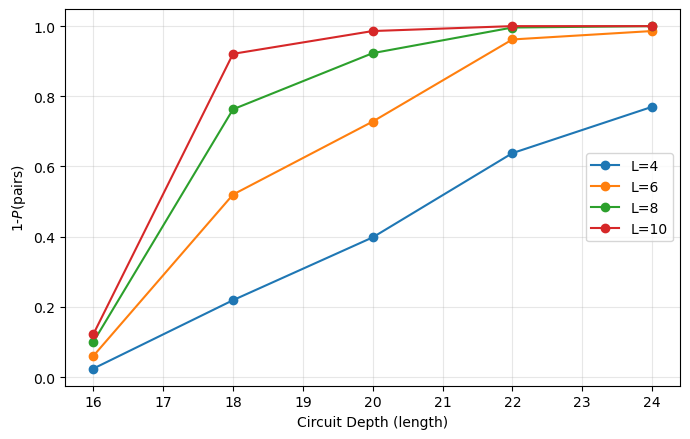

In [35]:
# Redraw the plot based on the reference
markers = ['o']
plt.figure(figsize=(7, 4.5))
for i, n in enumerate(sizes):
    y = [1 - p for p in results[n]["p_bot_pairs"]] # p_bot_pairs vs p_mode_topo
    plt.plot(
        results[n]["lengths"],
        # results[n]["p_bot_pairs"],
        y,
        marker=markers[i % len(markers)],
        linestyle='-',
        label=f"L={n}",
    )

# plt.gca().invert_xaxis()  # bigger depth on the left, shorter on the right
plt.xlabel("Circuit Depth (length)")
# P_pairs vs P_topo
plt.ylabel(r"1-$P(\mathrm{pairs})$")
# plt.title("Bot's performance per Circuit Depth")
plt.grid(True, alpha=0.3)
plt.legend(loc='center right', frameon=True)
plt.tight_layout()
plt.show()


# Run this on `FakeMiami`

- fake 120 qubit backend, included in `FakeBackendV2`.
- `from qiskit_ibm_runtime.fake_provider import FakeMiami`

In [ ]:
# (Optional) Run this cell if it's been a while you installed qiskit and qiskit-ibm-runtime on your machine.
!pip install --upgrade qiskit-ibm-runtime # FakeMiami is relatively new (May 2026: v0.47.0)

In [8]:
from qiskit_ibm_runtime.fake_provider.backends.miami import FakeMiami
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import SamplerV2

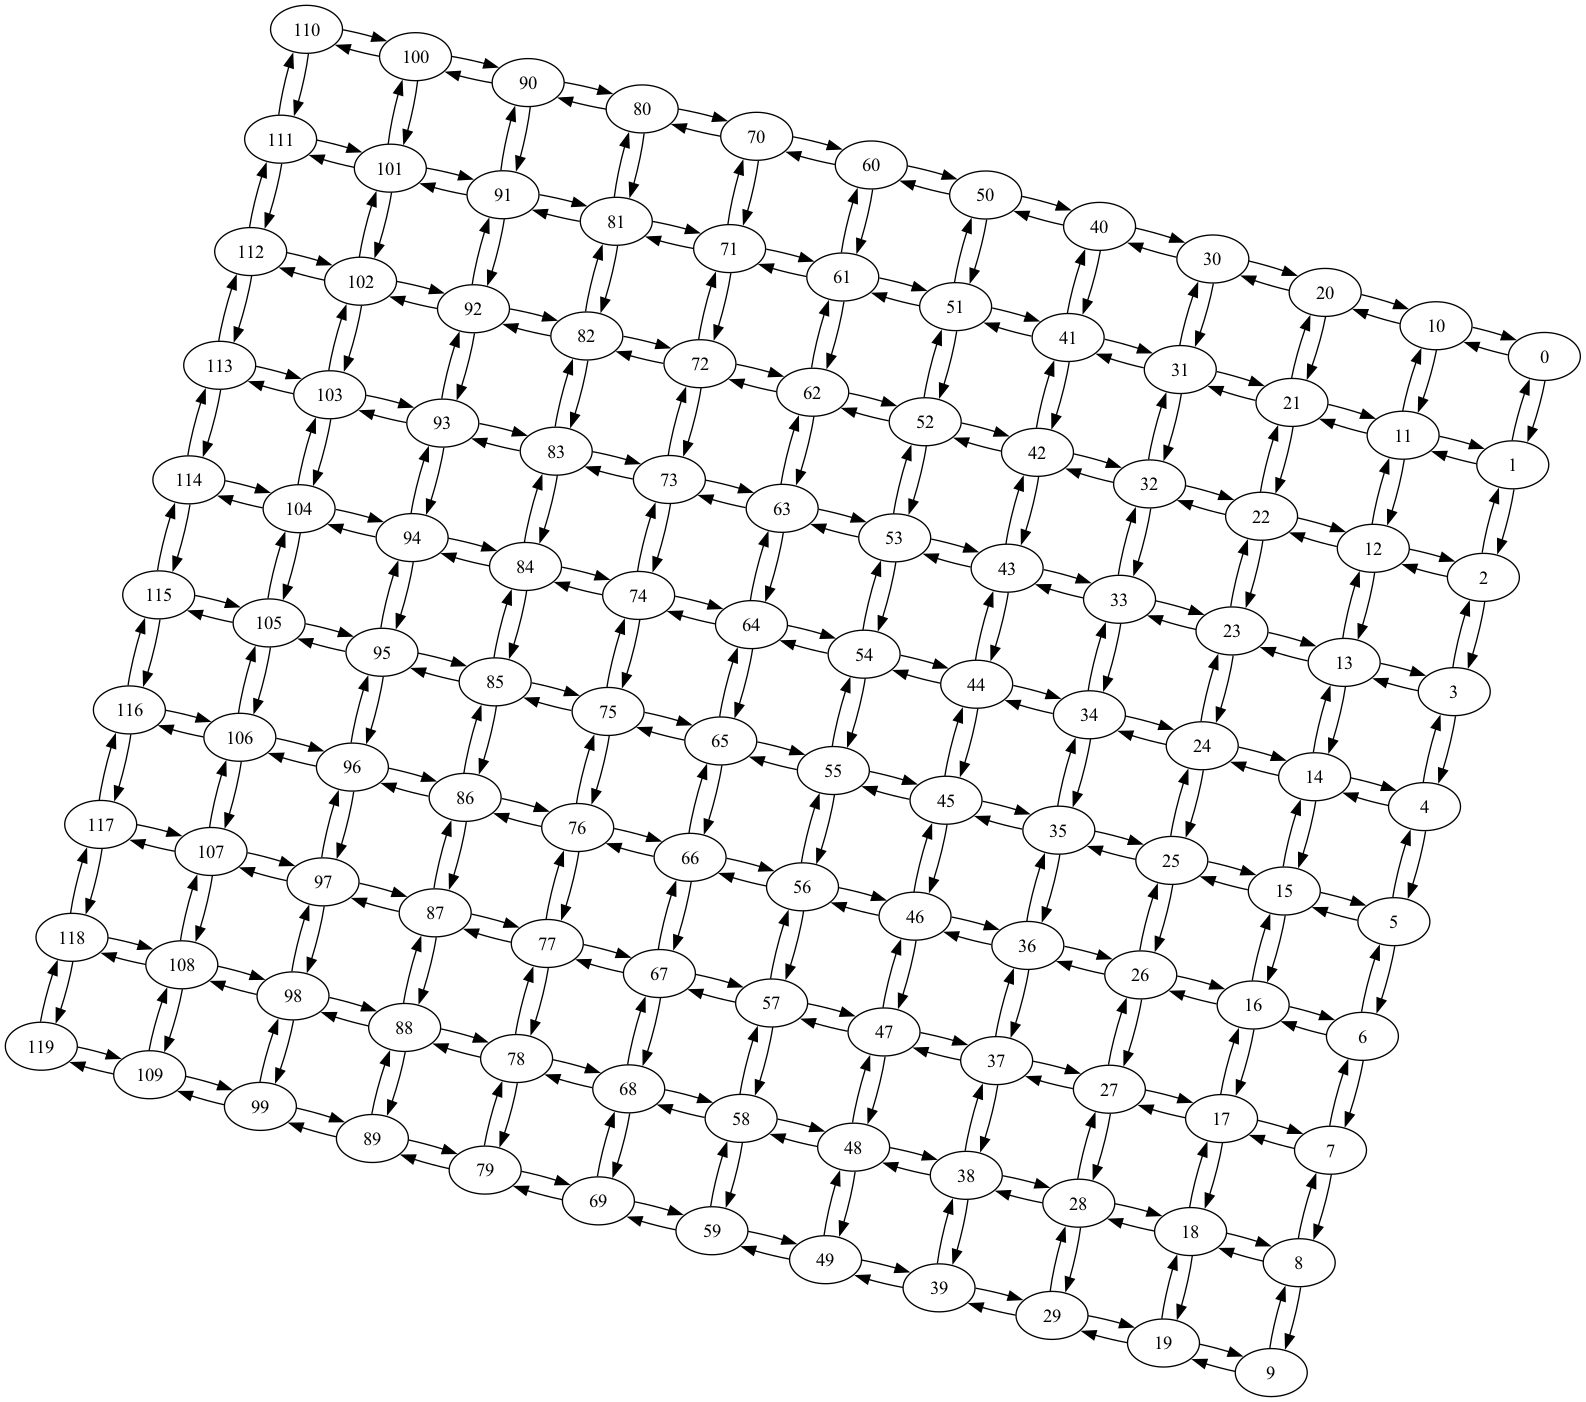

In [5]:
test = FakeMiami() # FakeMiami is a square lattice!
test.coupling_map.draw()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os, random, gc, pickle, pathlib
from collections import defaultdict
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.transpiler import Target
from qiskit.quantum_info import Operator
from qiskit_device_benchmarking.bench_code.mrb import (
    MirrorQATopo,
    QuantumAwesomeness,
    TopoUtil,
)

SEED = 123
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# --- Experiment parameters (shared across every lattice) ---
basis_gates = ["id", "h", "x", "y", "z", "rz", "cx"]
p2 = 1e-3 # 0.01%
# p2 = 1e-2 # 0.1%
# 5% error rate:
# p2 = 5e-2  # 1e-3 (0.1%), 1e-2 (1%), 5e-2 (5%)
# 10% error rate:
# p2 = 1e-1
# 20% error rate: (Update: We don't need this because from 10% it's already so random)
# p2 = 2e-1
p1 = p2 / 10
rz_angle = np.pi / 2
shots = 1000
# 10, 15, 20, 25 (potential intercept: 20)
# All lengths must be even so slightly changed the numbers
lengths = [0, 4, 12, 22, 30]
num_samples = 100  # Simulator: 1000, H/W: 100?
num_lengths = len(lengths)

In [18]:
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeMiami

# --- 1. Hardware Setup ---
miami_hw = FakeMiami()
leqit = miami_hw.num_qubits  # 120 qubits
faqe = leqit + 2  # 122 for the bot evaluation logic

# --- 2. Build Stabilizer-Compatible Noise Model ---
# CONVENTION: We extract Miami's gate errors but skip Thermal Relaxation.
# This removes the "Kraus" instructions that cause the stabilizer method to fail.
clifford_noise = NoiseModel.from_backend(miami_hw, thermal_relaxation=False)

# --- 3. Configure the Simulator ---
# We build the simulator FROM the backend so it inherits the 120-qubit coupling map.
miami_sim = AerSimulator.from_backend(miami_hw, noise_model=clifford_noise)
miami_sim.set_options(
    method="stabilizer",
    seed_simulator=SEED,
    # max_parallel_threads=0,  # Use all available CPU cores
    max_parallel_experiments=0,  # Run multiple circuits in parallel
)

# --- 4. Initialize the Experiment ---
# Note: If num_samples is 1000, this will still take a while.
# Consider reducing to 50-100 for testing.
exp_hw = MirrorQATopo(
    range(leqit),
    lengths=lengths,
    sampling_algorithm="topo",
    mode="random",
    backend=miami_sim,
    two_qubit_gate_density=0.5,
    num_samples=num_samples,
    initial_entangling_angle=np.pi / 2,
    seed=SEED,
)

# --- 5. Optimization & Run Options ---
exp_hw.set_run_options(shots=shots)

# CRITICAL: optimization_level=0 stops the 12-hour transpilation hang.
# Since MirrorQA is already topology-aware, we don't need the transpiler to "think."
exp_hw.set_transpile_options(optimization_level=0)

# --- 6. Execution ---
print(f"Starting experiment on FakeMiami ({leqit} qubits)...")
print(f"Processing {num_samples} samples across {len(lengths)} lengths.")

rb_data_hw = exp_hw.run()
rb_data_hw.block_for_results()  # Ensure we wait for the Aer job to finish

# --- 7. Data Extraction & Bot Evaluation ---
mi_hw = extract_mi(exp_hw, rb_data_hw, leqit)
results_hw = {}
results_hw["miami"] = evaluate_bot(mi_hw, exp_hw, leqit, faqe, verbose=False)
print(f"P(bot=pairs): {results_hw['miami']['p_bot_pairs']}")

Starting experiment on FakeMiami (120 qubits)...
Processing 20 samples across 5 lengths.
P(bot=pairs): [0.15, 0.05, 0.1, 0.1, 0.05]


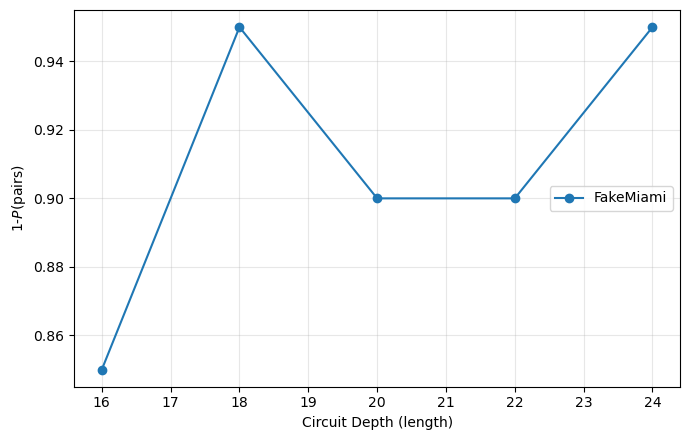

In [19]:
# Draw a plot for FakeMiami
plt.figure(figsize=(7, 4.5))
y = [1 - p for p in results_hw["miami"]["p_bot_pairs"]]  # 'p_bot_pairs' or 'p_mode_topo'
plt.plot(
    results_hw["miami"]["lengths"],
    y,
    marker='o',
    linestyle='-',
    label='FakeMiami',
)
plt.xlabel('Circuit Depth (length)')
plt.ylabel(r"1-$P(\mathrm{pairs})$") # 'pairs' or 'topo'
plt.grid(True, alpha=0.3)
plt.legend(loc='center right', frameon=True)
plt.tight_layout()
plt.show()